In [8]:
# ── Cell 1: Mount Drive & Unzip ───────────────────────────────
# Only needs to run once per session. Comment out after first run.
# from google.colab import drive
# drive.mount('/content/drive')

# !unzip /content/drive/MyDrive/AppML/jpegs_all_over_6755.zip -d /content/Data_Full
# !unzip /content/drive/MyDrive/AppML/jpegs_all_under_equal_6755.zip -d /content/Data_Full
print('Done unzipping')

import os
print(f'Files in Data_Full: {len(os.listdir("/content/Data_Full"))}')

Done unzipping
Files in Data_Full: 316320


In [ ]:
# # Free the old session's memory
# import torch, gc
# del model
# gc.collect()
# torch.cuda.empty_cache()
# print(torch.cuda.memory_summary(abbreviated=True))

In [9]:
import os
import re
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
from tqdm.auto import tqdm
from torch.cuda.amp import autocast, GradScaler

print(f"PyTorch {torch.__version__}")

if torch.cuda.is_available():
    device = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")


PyTorch 2.11.0+cu128
Using device: cuda


In [10]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
#  CONFIGURE THESE
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DATA_DIR    = '/content/Data_Full'   # ← change this
IMG_SIZE    = 200
BATCH_SIZE  = 64
NUM_SAMPLES = -1
EPOCHS      = 40
LR          = 8.59e-5  # was 1e-3
VAL_SPLIT   = 0.2
DROPOUT     = 0.003    # was 0.3
PATIENCE    = 10       # early stopping patience
OUTPUT_DIR  = "output"
SEED        = 42
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

os.makedirs(OUTPUT_DIR, exist_ok=True)

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

In [11]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
!nvidia-smi
print(torch.cuda.memory_allocated() / 1024**3, "GB")  # should be ~0 after fresh kernel

Sun Jun  7 13:48:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   65C    P0             31W /   70W |   10185MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [12]:
# ── Dataset ───────────────────────────────────────────────────
class PopulationDataset(Dataset):
    VALID_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

    def __init__(self, root_dir, transform=None, num_samples=-1):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.samples = []

        for f in sorted(self.root_dir.iterdir()):
            if f.suffix.lower() in self.VALID_EXT:
                try:
                    numbers = re.findall(r"\d+", f.stem)
                    if not numbers:
                        raise ValueError
                    self.samples.append((f, int(numbers[-1])))
                except ValueError:
                    print(f"⚠ Skipping {f.name} — no target in name")

        # if num_samples > 0 or num_samples == -1:
        #     random.seed(SEED)
        #     random.shuffle(self.samples)
        #     self.samples = self.samples[:num_samples]

        targets = [t for _, t in self.samples]
        print(f"✓ Loaded {len(self.samples)} images")
        print(f"  Target range : {min(targets)} – {max(targets)}")
        print(f"  Mean / std   : {np.mean(targets):.1f} / {np.std(targets):.1f}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, target = self.samples[idx]
        img = Image.open(path).convert("L")           # greyscale → 1 channel
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(target, dtype=torch.float32)

In [13]:
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

In [14]:
# ── Split & loaders ───────────────────────────────────────────
full_dataset = PopulationDataset(DATA_DIR, transform=None, num_samples=NUM_SAMPLES)
print(f"full_dataset.samples: {full_dataset.samples[:5]}")  # show some samples to verify}")
random.seed(SEED)
all_samples = full_dataset.samples.copy()
random.shuffle(all_samples)

zeros    = sum(1 for _, t in all_samples if t == 0)
nonzeros = sum(1 for _, t in all_samples if t > 0)
print(f"Class 0 (not populated): {zeros}")
print(f"Class 1 (populated)    : {nonzeros}")

val_size      = int(len(all_samples) * VAL_SPLIT)
train_samples = all_samples[val_size:]
val_samples   = all_samples[:val_size]

print(val_samples[:10])  # show some samples to verify

class CachedDataset(Dataset):
    def __init__(self, samples, transform=None, img_size=IMG_SIZE):
        self.transform = transform
        self.cache = []
        for path, target in tqdm(samples, desc="Caching"):
            img = Image.open(path).convert("L").resize((img_size, img_size), Image.BILINEAR)
            self.cache.append((img.copy(), target))

    def __len__(self):
        return len(self.cache)

    def __getitem__(self, idx):
        img, target = self.cache[idx]
        if self.transform:
            img = self.transform(img)
        label = 0.0 if target == 0 else 1.0
        return img, torch.tensor(label, dtype=torch.float32)

train_dataset = CachedDataset(train_samples, transform=train_transform, img_size=IMG_SIZE)
val_dataset   = CachedDataset(val_samples,   transform=val_transform, img_size=IMG_SIZE)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=8, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=8, pin_memory=True)

print(f"Train: {len(train_dataset)}  |  Val: {len(val_dataset)}")

✓ Loaded 88869 images
  Target range : 0 – 201
  Mean / std   : 1.3 / 6.8
full_dataset.samples: [(PosixPath('/content/Data_Full/000001_100m_61201_6501_0.jpg'), 0), (PosixPath('/content/Data_Full/000001_100m_61201_6756_32.jpg'), 32), (PosixPath('/content/Data_Full/000002_100m_61202_6501_0.jpg'), 0), (PosixPath('/content/Data_Full/000002_100m_61202_6756_17.jpg'), 17), (PosixPath('/content/Data_Full/000003_100m_61203_6501_0.jpg'), 0)]
Class 0 (not populated): 78908
Class 1 (populated)    : 9961
[(PosixPath('/content/Data_Full/071580_100m_61482_6741_0.jpg'), 0), (PosixPath('/content/Data_Full/004997_100m_61429_6517_0.jpg'), 0), (PosixPath('/content/Data_Full/013723_100m_61237_6547_0.jpg'), 0), (PosixPath('/content/Data_Full/038635_100m_61222_6631_0.jpg'), 0), (PosixPath('/content/Data_Full/013770_100m_61284_6547_1.jpg'), 1), (PosixPath('/content/Data_Full/059159_100m_61482_6699_0.jpg'), 0), (PosixPath('/content/Data_Full/044412_100m_61337_6650_0.jpg'), 0), (PosixPath('/content/Data_Full/01

Caching:   0%|          | 0/71096 [00:00<?, ?it/s]

Caching:   0%|          | 0/17773 [00:00<?, ?it/s]

Train: 71096  |  Val: 17773


In [15]:
class CountCNN(nn.Module):
    def __init__(self, dropout=DROPOUT):
        super().__init__()

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2),
            )

        self.features = nn.Sequential(
            conv_block(1,   32),
            conv_block(32,  64),
            conv_block(64,  128),
            conv_block(128, 256),
            conv_block(256, 256),
        )
        self.pool = nn.AdaptiveAvgPool2d((4, 4))

        self.classifier = nn.Sequential(    # renamed from regressor
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(512, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 1),              # raw logit, no ReLU
        )

    def forward(self, x):
        return self.classifier(self.pool(self.features(x))).squeeze(1)


# model = CountCNN().to(device)
# print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

In [ ]:
# # ── Cell 11.5: Optuna HPO ─────────────────────────────────────
# import optuna
# from optuna.pruners import MedianPruner
# from optuna.samplers import TPESampler

# n_hpo = int(len(train_dataset) * 0.2)
# hpo_indices = random.sample(range(len(train_dataset)), n_hpo)
# hpo_subset = torch.utils.data.Subset(train_dataset, hpo_indices)

# def objective(trial):
#     lr            = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
#     dropout       = trial.suggest_float("dropout", 0.0, 0.5)
#     weight_decay  = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
#     batch_size    = trial.suggest_categorical("batch_size", [64, 128, 256, 512])
#     optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "AdamW", "SGD"])

#     _model = CountCNN(dropout=dropout).to(device)

#     opt_kwargs = dict(lr=lr, weight_decay=weight_decay)
#     if optimizer_name == "SGD":
#         opt_kwargs["momentum"] = 0.9
#     _optimizer = getattr(torch.optim, optimizer_name)(_model.parameters(), **opt_kwargs)

#     _train_loader = DataLoader(hpo_subset, batch_size=batch_size, shuffle=True,
#                             num_workers=0, pin_memory=True)
#     _val_loader = val_loader
#     _criterion = nn.BCEWithLogitsLoss()
#     _scaler    = torch.amp.GradScaler("cuda")

#     HPO_EPOCHS = 5  # short — just ranking configs

#     for epoch in tqdm(range(HPO_EPOCHS), desc=f"Trial {trial.number}", leave=False):
#         _model.train()
#         for imgs, targets in _train_loader:
#             imgs, targets = imgs.to(device), targets.to(device)
#             _optimizer.zero_grad()
#             with torch.autocast(device_type="cuda", dtype=torch.float16):
#                 loss = _criterion(_model(imgs), targets)
#             _scaler.scale(loss).backward()
#             _scaler.step(_optimizer)
#             _scaler.update()

#         # Validation
#         _model.eval()
#         val_loss = 0.0
#         with torch.no_grad():
#             for imgs, targets in _val_loader:
#                 imgs, targets = imgs.to(device), targets.to(device)
#                 with torch.autocast(device_type="cuda", dtype=torch.float16):
#                     val_loss += _criterion(_model(imgs), targets).item() * imgs.size(0)
#         val_loss /= len(_val_loader.dataset)

#         trial.report(val_loss, epoch)
#         if trial.should_prune():
#             raise optuna.exceptions.TrialPruned()
#         # at the end of objective(), before return val_loss
#     del _model, _optimizer
#     torch.cuda.empty_cache()
#     return val_loss


# study = optuna.create_study(
#     direction="minimize",
#     sampler=TPESampler(seed=SEED),
#     pruner=MedianPruner(n_startup_trials=5, n_warmup_steps=2),
# )
# study.optimize(objective, n_trials=30, timeout=3600)

# print("Best params:", study.best_params)

In [16]:
best = {
    "lr": 8.590847395090266e-05,
    "dropout": 0.0029985914779085687,
    "weight_decay": 0.00017033389914119428,
    "batch_size": 64,
    "optimizer": "Adam"
}

model = CountCNN(dropout=best["dropout"]).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

# Verify HPO values are correctly applied
print(f"\nHPO best params:")
for k, v in best.items():
    print(f"  {k}: {v}")

# Verify dropout layer specifically
for name, module in model.named_modules():
    if isinstance(module, nn.Dropout):
        print(f"\nDropout layer '{name}': p={module.p}")

Parameters: 4,483,873

HPO best params:
  lr: 8.590847395090266e-05
  dropout: 0.0029985914779085687
  weight_decay: 0.00017033389914119428
  batch_size: 64
  optimizer: Adam

Dropout layer 'classifier.3': p=0.0029985914779085687


In [31]:
import matplotlib.pyplot as plt
import torch.nn.functional as F

def grad_cam(image_path, show=True):
    model.eval()

    activations, gradients = {}, {}
    def fwd_hook(m, inp, out): activations["v"] = out.detach()
    def bwd_hook(m, gin, gout): gradients["v"] = gout[0].detach()

    # Hook onto the last conv block
    target_layer = model.features[-1]
    h1 = target_layer.register_forward_hook(fwd_hook)
    h2 = target_layer.register_full_backward_hook(bwd_hook)

    # Load and preprocess
    img = Image.open(image_path).convert("L")
    x = val_transform(img).unsqueeze(0).to(device)

    # Forward pass
    logit = model(x)
    prob  = torch.sigmoid(logit).item()
    model.zero_grad()
    logit.backward()

    # Grad-CAM
    acts    = activations["v"][0]           # (C, h, w)
    grads   = gradients["v"][0]             # (C, h, w)
    weights = grads.mean(dim=(1, 2))        # (C,)
    cam     = F.relu((weights[:, None, None] * acts).sum(0))
    cam     = cam / (cam.max() + 1e-8)
    cam     = F.interpolate(cam[None, None], size=(IMG_SIZE, IMG_SIZE),
                            mode="bilinear", align_corners=False)[0, 0].cpu().numpy()

    h1.remove(); h2.remove()

    pred_label = "Populated" if prob > 0.5 else "Not Populated"

    if show:
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        axes[0].imshow(img.resize((IMG_SIZE, IMG_SIZE)), cmap="gray")
        axes[0].set_title("Input"); axes[0].axis("off")
        axes[1].imshow(img.resize((IMG_SIZE, IMG_SIZE)), cmap="gray")
        axes[1].imshow(cam, cmap="jet", alpha=0.5)
        axes[1].set_title(f"Grad-CAM")
        axes[1].axis("off")
        fig.suptitle(f"Pred: {pred_label}  (p={prob:.2f})")
        plt.tight_layout(); plt.show()

    return prob, cam

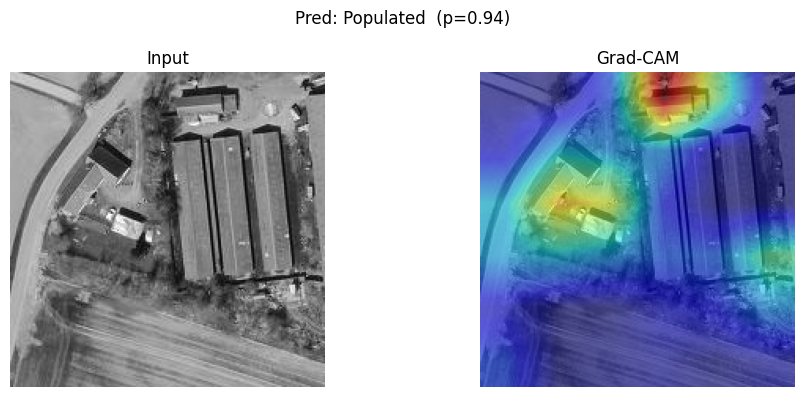

(0.9429605603218079,
 array([[0.020186  , 0.020186  , 0.020186  , ..., 0.00405137, 0.00405137,
         0.00405137],
        [0.020186  , 0.020186  , 0.020186  , ..., 0.00405137, 0.00405137,
         0.00405137],
        [0.020186  , 0.020186  , 0.020186  , ..., 0.00405137, 0.00405137,
         0.00405137],
        ...,
        [0.17820746, 0.17820746, 0.17820746, ..., 0.03895144, 0.03895144,
         0.03895144],
        [0.17820746, 0.17820746, 0.17820746, ..., 0.03895144, 0.03895144,
         0.03895144],
        [0.17820746, 0.17820746, 0.17820746, ..., 0.03895144, 0.03895144,
         0.03895144]], dtype=float32))

In [48]:


grad_cam(str(Path(os.path.join(OUTPUT_DIR, "false_positives")) / "038480_100m_61365_6630_0.jpg"))
# grad_cam("/content/Data_Full/000518_100m_61420_6502_8.jpg")
# !pip install grad_cam
# On a false negative (model missed populated area)
# fn_images = list(Path(os.path.join(OUTPUT_DIR, "true_negatives")).glob("*.jpg"))
# for p in fn_images[300:500]:
#     grad_cam(str(p))

In [17]:
# ── Training helpers ──────────────────────────────────────────
# n_zeros    = sum(1 for _, t in train_samples if t == 0)
# n_nonzeros = sum(1 for _, t in train_samples if t > 0)
# pos_weight = torch.tensor([n_zeros / n_nonzeros]).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=best["lr"], weight_decay=best["weight_decay"])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)
scaler    = torch.amp.GradScaler("cuda")


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss, all_preds, all_targets = 0.0, [], []
    for imgs, targets in tqdm(loader, desc="  train", leave=False):
        imgs, targets = imgs.to(device), targets.to(device)
        optimizer.zero_grad()
        with torch.autocast(device_type="cuda", dtype=torch.float16):
            logits = model(imgs)
            loss   = criterion(logits, targets)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item() * imgs.size(0)
        preds = (torch.sigmoid(logits) > 0.5).float()
        all_preds.extend(preds.detach().cpu().float().numpy())
        all_targets.extend(targets.cpu().numpy())
    acc = (np.array(all_preds) == np.array(all_targets)).mean()
    return running_loss / len(loader.dataset), acc

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss, all_preds, all_targets = 0.0, [], []
    for imgs, targets in loader:
        imgs, targets = imgs.to(device), targets.to(device)
        with torch.autocast(device_type="cuda", dtype=torch.float16):
            logits = model(imgs)
        running_loss += criterion(logits, targets).item() * imgs.size(0)
        preds = (torch.sigmoid(logits) > 0.5).float()
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())
    all_preds, all_targets = np.array(all_preds), np.array(all_targets)
    acc = (all_preds == all_targets).mean()
    return running_loss / len(loader.dataset), acc, all_preds, all_targets

In [ ]:
# ── Training loop ─────────────────────────────────────────────
best_val_loss    = float("inf")
patience_counter = 0
history          = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
import warnings
# print(f"\nStarting training for {EPOCHS} epochs...")
pbar = tqdm(range(1, EPOCHS + 1), desc="Epochs")
for epoch in pbar:
    warnings.filterwarnings("ignore")
    # print(f"\nEpoch {epoch}/{EPOCHS}")
    train_loss, train_acc       = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc, _, _     = evaluate(model, val_loader, criterion)
    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    pbar.set_postfix(t_loss=f"{train_loss:.4f}", v_loss=f"{val_loss:.4f}",
                     t_acc=f"{train_acc:.3f}", v_acc=f"{val_acc:.3f}")

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save({"epoch": epoch, "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "val_loss": float(val_loss), "val_acc": float(val_acc)},
                   os.path.join(OUTPUT_DIR, "best_model_full.pth"))
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\n⏹ Early stopping at epoch {epoch}")
            break

print(f"\n✓ Done — best val loss: {best_val_loss:.4f}")

In [18]:
# ── Final evaluation ──────────────────────────────────────────
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)

ckpt = torch.load("/content/drive/MyDrive/AppML/best_model_full.pth",
                  map_location=device, weights_only=False)

print(ckpt.keys())
# model.load_state_dict(ckpt["model_state_dict"])
print(f"Best model from epoch: {ckpt['epoch']}")
print(f"Val loss: {ckpt['val_loss']:.4f}, Val acc: {ckpt['val_acc']:.4f}")
model = CountCNN().to(device)
model.load_state_dict(ckpt['model_state_dict'])
val_loss, val_acc, preds, targets = evaluate(model, val_loader, criterion)

dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'val_loss', 'val_acc'])
Best model from epoch: 37
Val loss: 0.0676, Val acc: 0.9716


In [ ]:
# torch.save({
#     "epoch": epoch,
#     "model_state_dict": model.state_dict(),
#     "optimizer_state_dict": optimizer.state_dict(),
#     "val_loss": float(best_val_loss),
# }, os.path.join(OUTPUT_DIR, "final_model_full.pth"))

# # Save just the weights (smaller, for inference only)
# torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, "final_weights.pth"))

# print(f"✓ Saved to {OUTPUT_DIR}/")

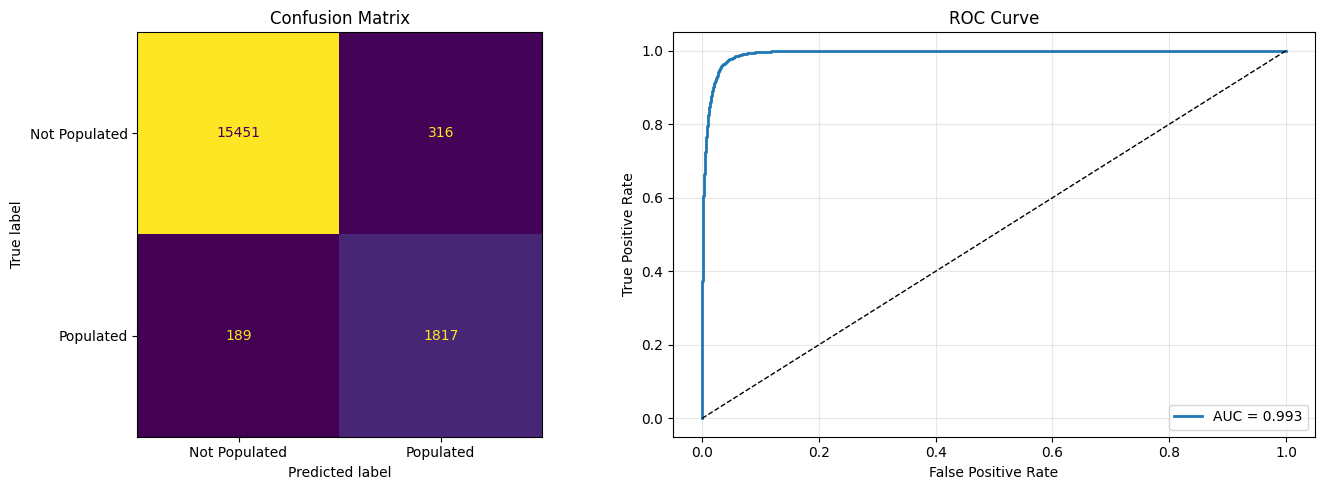

In [19]:
# ── Confusion matrix + ROC ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(targets, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=["Not Populated", "Populated"])
disp.plot(ax=axes[0], colorbar=False)
axes[0].set_title("Confusion Matrix")

model.eval()
all_probs = []
with torch.no_grad():
    for imgs, _ in val_loader:
        logits = model(imgs.to(device))
        all_probs.extend(torch.sigmoid(logits).cpu().numpy())

all_probs = np.array(all_probs)
auc = roc_auc_score(targets, all_probs)
fpr, tpr, _ = roc_curve(targets, all_probs)

axes[1].plot(fpr, tpr, linewidth=2, label=f"AUC = {auc:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1)
axes[1].set(title="ROC Curve", xlabel="False Positive Rate", ylabel="True Positive Rate")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "evaluation.png"), dpi=150)
plt.show()

In [ ]:
import shutil


MAX_PER_CLASS = 500  # adjust as needed
# ── Save all prediction groups ────────────────────────────────
tp_dir = os.path.join(OUTPUT_DIR, "true_positives")   # true=1, pred=1
tn_dir = os.path.join(OUTPUT_DIR, "true_negatives")   # true=0, pred=0
fp_dir = os.path.join(OUTPUT_DIR, "false_positives")  # true=0, pred=1
fn_dir = os.path.join(OUTPUT_DIR, "false_negatives")  # true=1, pred=0
for d in [tp_dir, tn_dir, fp_dir, fn_dir]:
    os.makedirs(d, exist_ok=True)

model.eval()
counts = {"tp": 0, "tn": 0, "fp": 0, "fn": 0}

with torch.no_grad():
    for i, (imgs, targets_b) in enumerate(val_loader):
        logits      = model(imgs.to(device))
        probs       = torch.sigmoid(logits).cpu()
        pred_labels = (probs > 0.5).float()

        for j in range(len(imgs)):
            true_label = int(targets_b[j].item())
            pred_label = int(pred_labels[j].item())
            prob       = probs[j].item()

            # Determine category
            if   true_label == 1 and pred_label == 1: cat, d = "tp", tp_dir
            elif true_label == 0 and pred_label == 0: cat, d = "tn", tn_dir
            elif true_label == 0 and pred_label == 1: cat, d = "fp", fp_dir
            elif true_label == 1 and pred_label == 0: cat, d = "fn", fn_dir

            if counts[cat] >= MAX_PER_CLASS:
                continue
            global_idx = i * val_loader.batch_size + j
            fname = Path(val_samples[global_idx][0]).name
            shutil.copy(val_samples[global_idx][0], os.path.join(d, fname))
            counts[cat] += 1

        # Stop early if all classes are full
        if all(v >= MAX_PER_CLASS for v in counts.values()):
            break

print(f"✓ Done")
print(f"  True  Positives : {counts['tp']}")
print(f"  True  Negatives : {counts['tn']}")
print(f"  False Positives : {counts['fp']}")
print(f"  False Negatives : {counts['fn']}")

In [ ]:
import shutil

drive_output = "/content/drive/MyDrive/AppML/predictions"
shutil.copytree(OUTPUT_DIR, drive_output, dirs_exist_ok=True)
print(f"✓ Copied to {drive_output}")

In [ ]:
import shutil
shutil.copy(os.path.join(OUTPUT_DIR, "best_model_full.pth"),
            "/content/drive/MyDrive/AppML/best_model_full.pth")
print("✓ Saved to Drive")